# 04 — Business Analysis & Storytelling
### Business Request 6: "What should management know about our sales performance?"

This notebook turns Notebook 03's exploration into a small number of
**evidence-based, decision-ready findings** — the analytical deliverable
this whole project has been building toward. Every finding below follows:

**Observation** (what happened) -> **Explanation** (what pattern in the data explains it) -> **Implication** (why it matters to the business) -> **Next question** (what to investigate next)

We do **not** claim causation the data can't support (see `data/README.md` — "Known limitations"). "Revenue was $X" is not a finding; "Revenue was $X, driven primarily by A, concentrated in B, suggesting C" is.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from extract_data import load_sales_data
from utils import add_time_features, apply_chart_style, CATEGORY_COLORS

%matplotlib inline
apply_chart_style()

sales = load_sales_data()
sales = add_time_features(sales, date_col='order_date', time_col='order_time')

20:21:40 | INFO    | Extracting full sales fact (order_details JOIN orders JOIN pizzas JOIN pizza_types)...


20:21:41 | INFO    | Extracted 48,620 rows, 13 columns.


---
## Finding 1 — Business Request 3/4: Category and timing headline numbers

In [2]:
kpis = {
    'Total revenue': f"${sales['total_price'].sum():,.2f}",
    'Total orders': f"{sales['order_id'].nunique():,}",
    'Total pizzas sold': f"{sales['quantity'].sum():,}",
    'Average order value': f"${sales['total_price'].sum() / sales['order_id'].nunique():,.2f}",
}
for k, v in kpis.items():
    print(f"{k:22s} {v}")

Total revenue          $817,860.05
Total orders           21,350
Total pizzas sold      49,574
Average order value    $38.31


> **Observation:** $817,860 in 2015 revenue across 21,350 orders (avg. order value $38.31).
> **Explanation:** driven by a broad, evenly-selling 32-flavor menu rather than one dominant product (Finding 2).
> **Implication:** the business isn't fragile to any single flavor falling out of favor.
> **Next question:** how concentrated IS revenue across the menu, exactly?

---
## Finding 2 — Business Request 3: Product concentration

Top 5 of 32 flavors generate 24.5% of total revenue


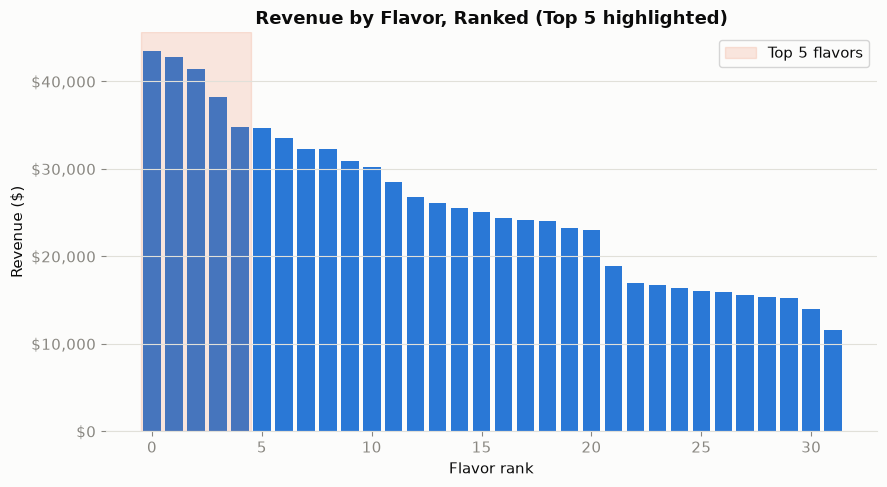

In [3]:
flavor_revenue = sales.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False)
top5_share = flavor_revenue.head(5).sum() / flavor_revenue.sum() * 100
print(f"Top 5 of 32 flavors generate {top5_share:.1f}% of total revenue")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(flavor_revenue)), flavor_revenue.values, color=CATEGORY_COLORS['Classic'])
ax.axvspan(-0.5, 4.5, color=CATEGORY_COLORS['Chicken'], alpha=0.15, label='Top 5 flavors')
ax.set_title('Revenue by Flavor, Ranked (Top 5 highlighted)')
ax.set_xlabel('Flavor rank')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

> **Observation:** the top 5 flavors (of 32) generate only ~24.5% of revenue.
> **Explanation:** the bar chart shows a gradual decline, not a cliff — there is no small group of "hero" products carrying the business.
> **Implication:** low concentration is a **resilience** strength (no single-product risk) but also means no flavor is a strong candidate for an outsized marketing push expecting outsized returns.
> **Next question:** are the flavors that sell the MOST units the same ones earning the MOST revenue?

---
## Finding 3 — Business Request 5: Volume vs. revenue mismatch

In [4]:
flavor_stats = (
    sales.groupby('pizza_name')
    .agg(units_sold=('quantity', 'sum'), revenue=('total_price', 'sum'))
)
flavor_stats['volume_rank'] = flavor_stats['units_sold'].rank(ascending=False)
flavor_stats['revenue_rank'] = flavor_stats['revenue'].rank(ascending=False)
flavor_stats['rank_gap'] = flavor_stats['revenue_rank'] - flavor_stats['volume_rank']

sells_better_than_it_earns = flavor_stats.sort_values('rank_gap', ascending=False).head(5)
sells_better_than_it_earns[['units_sold', 'revenue', 'volume_rank', 'revenue_rank']]

,units_sold,revenue,volume_rank,revenue_rank
pizza_name,,,,
The Big Meat Pizza,1914,22968.00,10.0,21.0
The Green Garden Pizza,997,13955.75,23.0,31.0
The Pepperoni Pizza,2418,30161.75,4.0,11.0
The Hawaiian Pizza,2422,32273.25,3.0,8.0
The Napolitana Pizza,1464,24087.00,15.0,19.0


> **Observation:** several flavors — led by The Pepperoni Pizza and The Hawaiian Pizza — rank much higher by units sold than by revenue (a large positive `rank_gap`).
> **Explanation:** cross-referencing against `sql/04_aggregation.sql`'s Level 6 HAVING exercise, these are exactly the flavors with the lowest average line-item value (~$12.70-$13.60) — they're popular AND cheap, so high volume doesn't translate to proportionally high revenue.
> **Implication:** these flavors work as **volume/traffic drivers**, not margin drivers — a real business would want COST data (which this dataset doesn't have, see `data/README.md` limitations) before concluding anything about actual profitability; we can only speak to revenue, not margin.
> **Next question:** does this pattern hold across pizza SIZE too, not just flavor?

---
## Finding 4 — Business Request 4: When does demand peak?

In [5]:
hourly_revenue = sales.groupby('order_hour')['total_price'].sum()
peak_hour = hourly_revenue.idxmax()
print(f"Highest-revenue hour: {peak_hour}:00, generating ${hourly_revenue.max():,.2f}")
print(f"That's {hourly_revenue.max() / hourly_revenue.sum() * 100:.1f}% of all revenue in a single hour of the day.")

Highest-revenue hour: 12:00, generating $111,877.90
That's 13.7% of all revenue in a single hour of the day.


> **Observation:** noon (12:00) is the single highest-revenue hour, matching the highest order-count hour (confirmed independently in `sql/04_aggregation.sql`'s Level 5 Business Challenge).
> **Explanation:** a clear lunch rush, with a second (smaller) dinner peak around 18:00-19:00 (Notebook 03, Theme 3).
> **Implication:** staffing and inventory prep should be weighted toward the lunch window specifically, not spread evenly across "midday."
> **Next question:** does the same peak hold on weekends, when lunch habits may differ?

---
## Finding 5 — Business opportunity: a genuine anomaly worth investigating

In [6]:
daily_revenue = sales.groupby(sales['order_date'])['total_price'].sum().sort_index()
rolling_avg = daily_revenue.rolling(window=7, min_periods=1).mean()
excess = (daily_revenue - rolling_avg).sort_values(ascending=False)
excess.head(3)

order_date
2015-11-26    1933.785714
2015-10-15    1813.521429
2015-11-27    1659.664286
Name: total_price, dtype: float64

> **Observation:** 2015-11-26 (U.S. Thanksgiving Day) and 2015-11-27 (the day after) are both far above their trailing 7-day average — matching the window-function finding in `sql/07_advanced_analysis.sql`.
> **Explanation:** a clustered, two-day spike around a specific U.S. holiday, not a random fluctuation — this is exactly the kind of pattern a rolling average is built to surface.
> **Implication:** if this repeats in future years' data (which we don't have — single-year limitation), it's a legitimate case for proactive holiday-week staffing and inventory planning.
> **Next question:** does the same spike appear around other major U.S. holidays in this dataset (July 4th, Christmas)? (Try it yourself — Your Turn, below.)

## Your Turn — Practice the storytelling framework yourself

Pick ONE and write all four steps (Observation / Explanation / Implication /
Next question) in markdown, backed by a query or chart:

1. Does Independence Day (2015-07-04) show the same kind of spike as Thanksgiving?
2. We found (Notebook 03) that order value doesn't vary much by day of week. Does it vary by `time_of_day` instead?
3. **Challenge:** Business Request 5 asked about "sell frequently but contribute little revenue" — using `flavor_stats`, define your own explicit threshold for what counts as "frequent but low-revenue," and produce a specific, named list of flavors that meet it. Defend your threshold choice in a sentence.

In [7]:
# Your code here


## From here

These five findings, plus Notebook 03's exploratory charts, are the
evidence base for `reports/insights.md` (the executive-facing writeup) and
for the Streamlit dashboard (`dashboard/app.py`) — the same numbers,
computed the same way, presented to two different audiences (a written
report vs. an interactive tool).